In [1]:
!python -m pip install -r requirements.txt
import os
import torch
import clip
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\aandr\AppData\Local\Temp\pip-req-build-u4v1g5wo'


  Cloning https://github.com/openai/CLIP.git to C:\Users\aandr\AppData\Local\Temp\pip-req-build-u4v1g5wo
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369674 sha256=3ee6b2b7dae04c3278555ff1075a9374da5e4593a50d5f8a886409265b3a9c0d
  Stored in directory: C:\Users\aandr\AppData\Local\Temp\pip-ephem-wheel-cache-jhh17jqj\wheels\96\4f\3b\3ee9011cf15cdc43dd9e65bdac4faec855ebb4d34beef2f362
Successfully built clip

   ---------------------------------------- 0/2 [ftfy]
   -------------------- ------------------- 1/2 [clip]
   -----------------------------

# Parte 1 - Clasificación Zero-Shot con CLIP
## 1.1 Carga del modelo CLIP

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

100%|███████████████████████████████████████| 338M/338M [00:18<00:00, 18.6MiB/s]


## 1.2 Parametros e imagenes para el modelo

In [7]:
base_path = "../Covid19-dataset"
class_names = ["Covid", "Normal", "Viral Pneumonia"]
descriptions = [
    "a chest X-ray showing COVID-19 pneumonia",
    "a normal healthy chest X-ray",
    "a chest X-ray showing viral pneumonia"
]

# Tokenizar los textos para CLIP
text_inputs = clip.tokenize(descriptions).to(device)

test_images = {
    "Covid": base_path + "/test/Covid/094.png",
    "Normal": base_path + "/test/Normal/0114.jpeg",
    "Viral Pneumonia": base_path + "/test/Viral Pneumonia/0101.jpeg"
}

## 1.3 Clasificación y gráficas

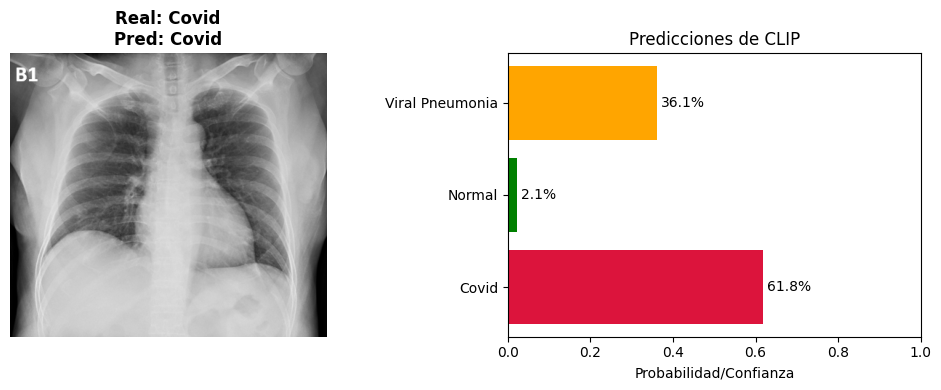

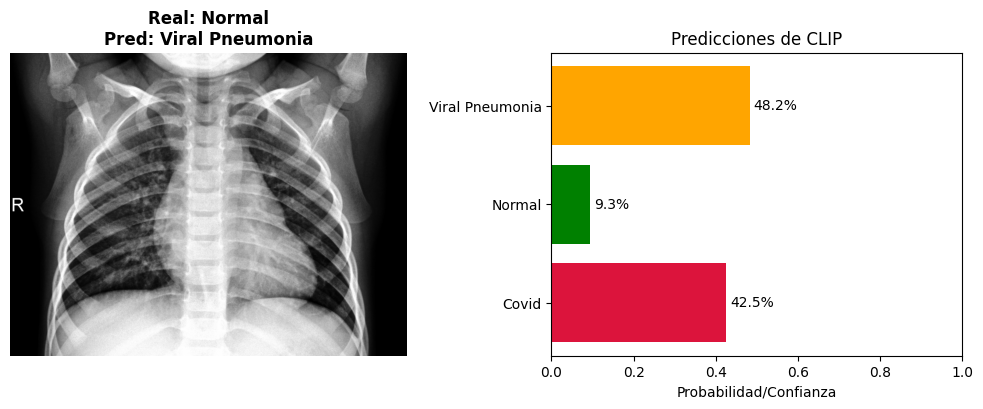

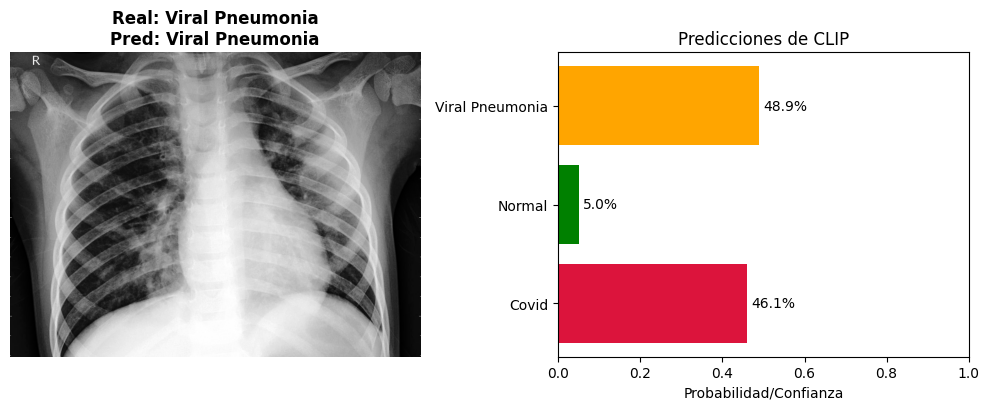

In [ ]:
for true_label, img_path in test_images.items():
    if not os.path.exists(img_path):
        print(f"Archivo no encontrado: {img_path}. Saltando ejemplo...")
        continue
        
    # Cargar y preprocesar la imagen
    image_raw = Image.open(img_path).convert("RGB")
    image_input = preprocess(image_raw).unsqueeze(0).to(device)
    
    # Inferencia con CLIP
    with torch.no_grad():
        logits_per_image, _ = model(image_input, text_inputs)
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
    
    # Predicción con mayor probabilidad
    pred_idx = np.argmax(probs)
    pred_label = class_names[pred_idx]
    
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    # Mostrar Rayos X
    ax1.imshow(image_raw, cmap='gray')
    ax1.set_title(f"Real: {true_label}\nPred: {pred_label}", fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    # Mostrar Gráfica de barras de confianza
    bars = ax2.barh(class_names, probs, color=['crimson', 'g', 'orange'])
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Probabilidad/Confianza')
    ax2.set_title('Predicciones de CLIP')
    
    # Añadir porcentajes a las barras
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width*100:.1f}%', 
                 va='center', ha='left', fontsize=10)
                 
    plt.tight_layout()
    plt.show()


# Parte 2 - Clasificador Tradicional

## 2.1 Carga del modelo ResNet

In [9]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = torch.nn.Identity()  # Removemos la capa de clasificación final
resnet.eval()
resnet.to(device)

resnet_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\aandr/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 17.7MB/s]


## 2.2 Imagenes cargadas y preparadas para ser usadas con el modelo

In [37]:
class_mapping = {"Covid": 0, "Normal": 1, "Viral Pneumonia": 2}

train_features = []
train_labels = []

for class_name, class_idx in class_mapping.items():
    class_folder = os.path.join(base_path, "train", class_name)
    if not os.path.exists(class_folder):
        print(f"Advertencia: No se encontró la carpeta {class_folder}")
        continue
        
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        try:
            # Cargar imagen y pasar por ResNet
            img = Image.open(img_path).convert("RGB")
            tensor = resnet_transforms(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                feat = resnet(tensor).cpu().numpy().flatten()
            
            train_features.append(feat)
            train_labels.append(class_idx)
        except Exception as e:
            # Saltar archivos que no se puedan abrir
            continue
        
train_features = np.array(train_features)
train_labels = np.array(train_labels)

test_features = []
test_labels = []

graph = { os.path.abspath(k): None for k in test_images.values() }

#repetir lo mismo para las de entrenamiento
for class_name, class_idx in class_mapping.items():
    class_folder = os.path.join(base_path, "test", class_name)
    if not os.path.exists(class_folder):
        print(f"Advertencia: No se encontró la carpeta {class_folder}")
        continue
        
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        if os.path.abspath(img_path) in graph:
            graph[img_name] = len(test_features)
        try:
            img = Image.open(img_path).convert("RGB")
            tensor = resnet_transforms(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                feat = resnet(tensor).cpu().numpy().flatten()
            
            test_features.append(feat)
            test_labels.append(class_idx)
        except Exception as e:
            continue


test_features = np.array(test_features)
test_labels = np.array(test_labels)

## 2.3 Clasificador entrenado y usado con imágenes de test

In [29]:
svm_classifier = SVC(kernel='linear', C=1.0)
svm_classifier.fit(train_features, train_labels)

y_pred_svm = svm_classifier.predict(test_features)
svm_accuracy = accuracy_score(test_labels, y_pred_svm)

print("\n=== RENDIMIENTO CLASIFICADOR TRADICIONAL (ResNet + SVM) ===")
print(f"Precisión Global (Accuracy): {svm_accuracy:.2%}")
print("\nReporte de Clasificación:")
print(classification_report(test_labels, y_pred_svm, target_names=["Covid", "Normal", "Viral Pneumonia"]))


=== RENDIMIENTO CLASIFICADOR TRADICIONAL (ResNet + SVM) ===
Precisión Global (Accuracy): 92.42%

Reporte de Clasificación:
                 precision    recall  f1-score   support

          Covid       0.96      0.88      0.92        26
         Normal       0.95      0.95      0.95        20
Viral Pneumonia       0.86      0.95      0.90        20

       accuracy                           0.92        66
      macro avg       0.92      0.93      0.92        66
   weighted avg       0.93      0.92      0.92        66



## 2.4 Comparación con CLIP

In [30]:
#clip ya debe estar cargado con la parte 1

clip_correct = 0
total_samples = 0

for class_name, class_idx in class_mapping.items():
    class_folder = os.path.join(base_path, "test", class_name)
    if not os.path.exists(class_folder): continue
    
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        try:
            img = Image.open(img_path).convert("RGB")
            img_input = preprocess(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                logits_per_image, _ = model(img_input, text_inputs)
                pred = logits_per_image.argmax(dim=-1).item()
                
            if pred == class_idx:
                clip_correct += 1
            total_samples += 1
        except:
            continue

clip_accuracy = clip_correct / total_samples if total_samples > 0 else 0
print("\n=== COMPARATIVA FINAL ===")
print(f"Precisión SVM (Supervisado tradicional): {svm_accuracy * 100:.2f}%")
print(f"Precisión CLIP (Zero-Shot sin entrenar): {clip_accuracy * 100:.2f}%")


=== COMPARATIVA FINAL ===
Precisión SVM (Supervisado tradicional): 92.42%
Precisión CLIP (Zero-Shot sin entrenar): 53.03%


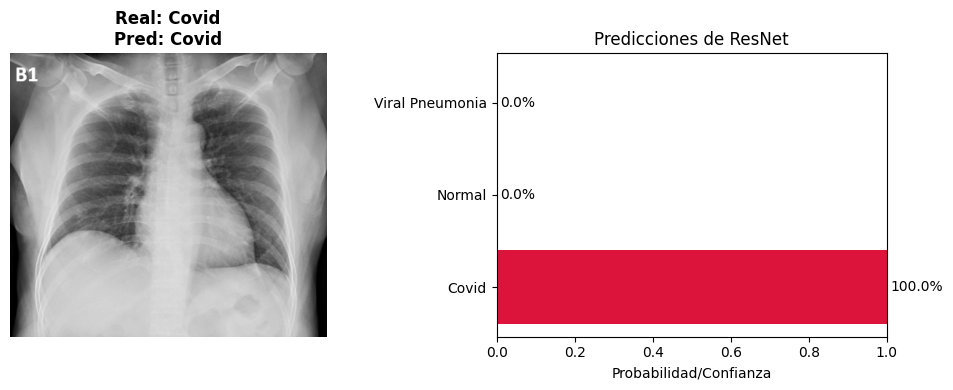

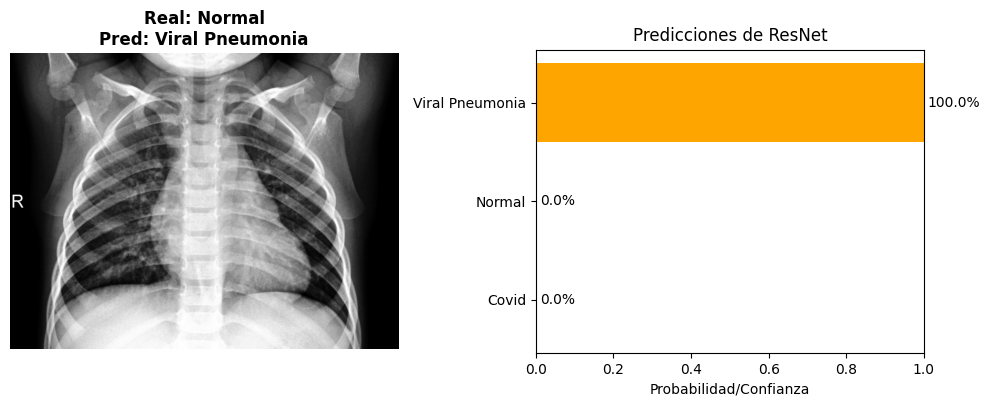

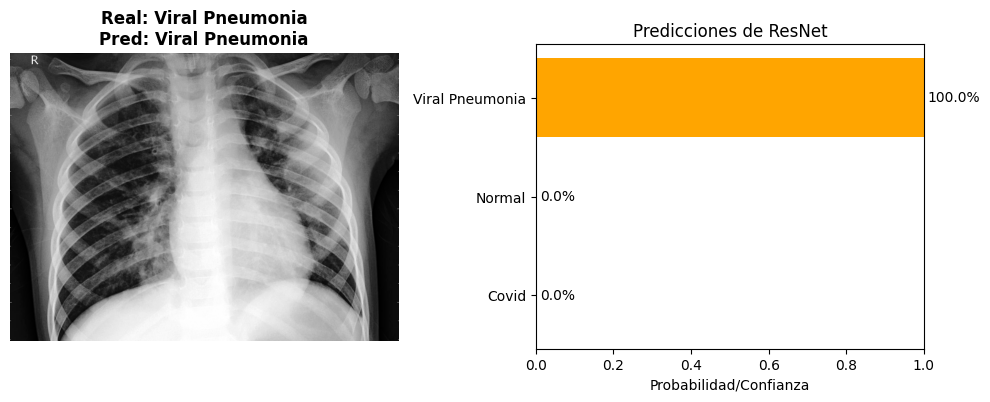

In [43]:
for true_label, img_path in test_images.items():
    if not os.path.exists(img_path):
        print(f"Archivo no encontrado: {img_path}. Saltando ejemplo...")
        continue
        
    image_raw = Image.open(img_path).convert("RGB")
    
    pred_idx = y_pred_svm[graph[os.path.basename(img_path)]]
    pred_label = class_names[pred_idx]
    
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    # Mostrar Rayos X
    ax1.imshow(image_raw, cmap='gray')
    ax1.set_title(f"Real: {true_label}\nPred: {pred_label}", fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    # Mostrar Gráfica de barras de confianza
    bars = ax2.barh(class_names, [(i == pred_idx)*1 for i in range(3)], color=['crimson', 'g', 'orange'])
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Probabilidad/Confianza')
    ax2.set_title('Predicciones de ResNet')
    
    # Añadir porcentajes a las barras
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.1%}', 
                 va='center', ha='left', fontsize=10)
                 
    plt.tight_layout()
    plt.show()